In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import seaborn as sns
from datetime import timedelta
import matplotlib.ticker as tkr
from sklearn.cluster import KMeans

def custom_grouping(index):
    return index // 1000

names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
#df = pd.read_csv(f'/home/surbhi/measurements/worst_case/STL/1M/90-10-LBA/90Util/run1/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)

In [3]:
df1 = pd.read_csv('/home/surbhi/measurements/STL/cache/uniform-random/8HourPause/run1/lat_log_avg_lat.1.log', sep=',', names=names_latency, usecols=columns)
# Convert nanoseconds to microseconds for the 'time' column
df1['duration'] = df1['duration'] / 1000000  # Convert nanoseconds to milliseconds
# Calculate cumulative GBs of data written
df1['cumulative_gb'] = np.floor(df1['write_size'].cumsum() / (1024**3))
df1['submission_time'] = df1['submission_time'] - df1.iloc[0].submission_time
df1['completion_time'] = np.floor(df1['submission_time'] + df1['duration'])

In [4]:
# Step 3: Determine the start and end time of the entire test
start_time = int(df1['submission_time'].min())
end_time = int(math.ceil(df1['completion_time'].max()))


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms1 = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms1['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df1.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms1.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms1.loc[end] += residue

print(index)
data_written_ms1.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms1[data_written_ms1.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms1.loc[:last_non_zero_index]

/tmp/ipykernel_122310/507860518.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[442407.63695922 442407.63695922]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_written_ms1.loc[start:end-1] += write_rate_per_ms


35839


In [5]:
chunk_size = 10000
results = []
for i in range(0, len(data_written_ms1), chunk_size):
    chunk = data_written_ms1.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped1 = pd.concat(results)

# Reset the index to make it a regular column
df_grouped1.reset_index(inplace=True)
df_grouped1['cumulative_gb'] = df_grouped1['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped1['data_written_bytes'] = df_grouped1['data_written_bytes'] / (1024 ** 2) 
df_grouped1.reset_index(drop=True, inplace=True)
last_non_zero_index = df_grouped1[df_grouped1.ne(0).any(axis=1)].index[-1]
df_grouped1 = df_grouped1.loc[:last_non_zero_index]
df_grouped1['latency'] =1 / df_grouped1['data_written_bytes']
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped1.describe())
print(df_grouped1.info())


            index  data_written_bytes  cumulative_gb      latency
count  1369.00000         1369.000000    1369.000000  1369.000000
mean    684.00000           26.179693      28.479923          inf
std     395.34057           43.754078       7.713478          NaN
min       0.00000            0.000000       0.109455     0.007055
25%     342.00000            6.319358      28.701926     0.154802
50%     684.00000            6.366108      30.825953     0.157082
75%    1026.00000            6.459867      32.933476     0.158244
max    1368.00000          141.745710      35.000000          inf
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1369 entries, 0 to 1368
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               1369 non-null   int64  
 1   data_written_bytes  1369 non-null   float64
 2   cumulative_gb       1369 non-null   float64
 3   latency             1369 non-null   float64
dtypes

/home/surbhi/.local/lib/python3.10/site-packages/pandas/core/nanops.py:1010: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [6]:
df2= pd.read_csv('/home/surbhi/measurements/STL/cache/uniform-random/8HourPause/run2/lat_log_avg_lat.1.log', sep=',' , names=names_latency, usecols=columns)
# Convert nanoseconds to microseconds for the 'time' column
df2['duration'] = df2['duration'] / 1000000  # Convert nanoseconds to milliseconds
# Calculate cumulative GBs of data written
df2['cumulative_gb'] = np.floor(df2['write_size'].cumsum() / (1024**3))
df2['submission_time'] = df2['submission_time'] - df2.iloc[0].submission_time #+ df_grouped1.index.max() + 60 * 60
df2['completion_time'] = np.floor(df2['submission_time'] + df2['duration'])

In [7]:
# Step 3: Determine the start and end time of the entire test
start_time = int(df2['submission_time'].min())
end_time = int(df2['completion_time'].max())

# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms2 = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms2['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df2.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms2.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms2.loc[end] += residue

print(index)
data_written_ms2.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms2[data_written_ms2.ne(0).any(axis=1)].index[-1]
data_written_ms2 = data_written_ms2.loc[:last_non_zero_index]

/tmp/ipykernel_122310/840144846.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[17578.06210321 17578.06210321 17578.06210321 17578.06210321
 17578.06210321 17578.06210321 17578.06210321 17578.06210321
 17578.06210321 17578.06210321 17578.06210321 17578.06210321
 17578.06210321 17578.06210321 17578.06210321 17578.06210321
 17578.06210321 17578.06210321 17578.06210321 17578.06210321
 17578.06210321 17578.06210321 17578.06210321 17578.06210321
 17578.06210321 17578.06210321 17578.06210321 17578.06210321
 17578.06210321 17578.06210321 17578.06210321 17578.06210321
 17578.06210321 17578.06210321 17578.06210321 17578.06210321
 17578.06210321 17578.06210321 17578.06210321 17578.06210321
 17578.06210321 17578.06210321 17578.06210321 17578.06210321
 17578.06210321 17578.06210321 17578.06210321 17578.06210321
 17578.06210321 17578.06210321 17578.06210321 17578.06210321
 17578.06210321 17578.06210321 17578.06210321 1757

35839


In [8]:
chunk_size = 100000
results = []

for i in range(0, len(data_written_ms2), chunk_size):
    chunk = data_written_ms2.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped2 = pd.concat(results)

# Reset the index to make it a regular column
df_grouped2.reset_index(inplace=True)
df_grouped2['cumulative_gb'] = df_grouped2['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped2['data_written_bytes'] = df_grouped2['data_written_bytes'] / (1024 ** 2) 
df_grouped2.reset_index(drop=True, inplace=True)
last_non_zero_index = df_grouped2[df_grouped2.ne(0).any(axis=1)].index[-1]
df_grouped2 = df_grouped2.loc[:last_non_zero_index]
df_grouped2['latency'] =1 / df_grouped2['data_written_bytes']
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped2.describe())
print(df_grouped2.info())

             index  data_written_bytes  cumulative_gb      latency
count  4417.000000         4417.000000    4417.000000  4417.000000
mean   2208.000000            8.114105      19.589402          inf
std    1275.222399           11.831788       8.843025          NaN
min       0.000000            0.000000       0.082855     0.007401
25%    1104.000000            6.157087      11.771122     0.139574
50%    2208.000000            6.342926      19.405398     0.157656
75%    3312.000000            7.164648      27.291452     0.162414
max    4416.000000          135.121713      35.000000          inf
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4417 entries, 0 to 4416
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               4417 non-null   int64  
 1   data_written_bytes  4417 non-null   float64
 2   cumulative_gb       4417 non-null   float64
 3   latency             4417 non-null   float

/home/surbhi/.local/lib/python3.10/site-packages/pandas/core/nanops.py:1010: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


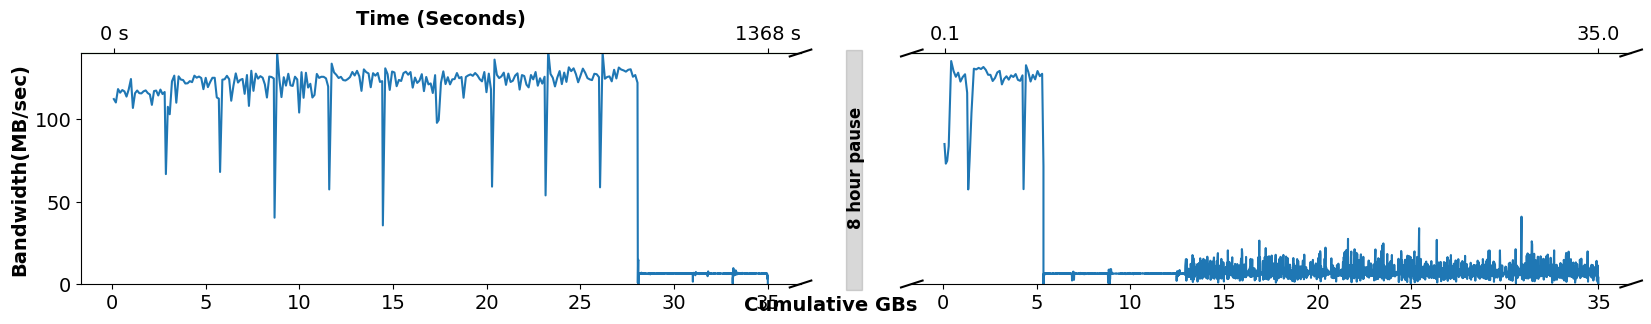

In [14]:

from matplotlib.patches import Rectangle
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

# Create the main plot
#fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 4), layout='constrained', sharey=True)
# Create a figure and GridSpec
fig = plt.figure(figsize=(20, 3))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 0.02, 1], wspace=0.1)  # Adjust width_ratios and wspace as needed

# Create subplots
ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[2])

# Set labels for the primary x-axis and y-axis
#ax1.set_xlabel("Cumulative GBs")
fig.supxlabel("Cumulative GBs", fontsize=14, weight="bold")
ax1.set_ylabel("Bandwidth(MB/sec)", fontsize=14, weight="bold")
ax1.spines['right'].set_visible(False)
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)

# Optionally, remove the right y-ticks
ax1.yaxis.set_ticks_position('left')  # Only show ticks on the left side
ax1.spines['right'].set_visible(False)

for ax in [ax1, ax2]:
    ax.set_ylim(0, 140)

# Customize spines and ticks
for ax in [ax2]:
    # Hide all spines and ticks initially
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='both', left=False, right=False, labelleft=False, labelright=False)


# Map the ticks from the primary axis (cumulative_gbs) to the corresponding time values
tick_locations = np.linspace(df_grouped1['cumulative_gb'].min(), df_grouped1['cumulative_gb'].max(), 2)  # Choose tick locations (e.g., 5 ticks)
corresponding_time_values1 = np.interp(tick_locations, df_grouped1['cumulative_gb'], df_grouped1.index)  # Interpolate corresponding time values

secax1 = ax1.secondary_xaxis('top')
#Set the ticks and their labels on the secondary axis
secax1.set_xticks(tick_locations)
secax1.set_xticklabels([f"{int(val)} s" for val in corresponding_time_values1])  # Format as seconds
df_grouped1['seconds'] = pd.to_numeric(df_grouped1.index)
df_grouped2['seconds'] = pd.to_numeric(df_grouped2.index)
maxindex = df_grouped1.iloc[-1].seconds + df_grouped2.iloc[-1].seconds
secax1.set_xlim(0, maxindex)
secax1.spines['top'].set_linestyle((0, (1, 1)))  # Dotted pattern (0, (1, 1))
secax1.spines['top'].set_color('green')          # Set the color to green
secax1.tick_params(axis='x', labelsize=14)     # Set the ticks color to green


 # Choose tick locations (e.g., 5 ticks)
#tick_locations = np.linspace(df_grouped2['cumulative_gb'].min(), df_grouped2['cumulative_gb'].max(), 2)
#corresponding_time_values1 = np.interp(tick_locations, df_grouped2['cumulative_gb'], df_grouped2.time)  # Interpolate corresponding time values
secax2 = ax2.secondary_xaxis('top')
# Set the ticks and 
secax2.spines['top'].set_linestyle((0, (1, 1)))  # Dotted pattern (0, (1, 1))
secax2.spines['top'].set_color('green')          # Set the color to green
secax2.tick_params(axis='x' , labelsize=14)     # Set the ticks color to greentheir labels on the secondary axis
secax2.set_xticks(tick_locations)
#secax2.set_xticklabels([f"{int(val)} s" for val in corresponding_time_values1])  # Format as seconds

ax2.tick_params(axis='x', labelsize=14)

#secax2.sharex(secax1)
ax1.plot(df_grouped1['cumulative_gb'], df_grouped1['data_written_bytes'], label="Run1")
#df_grouped2['cumulative_gb'] = df_grouped2['cumulative_gb'] + df_grouped1.iloc[-1].cumulative_gb
ax2.plot(df_grouped2['cumulative_gb'], df_grouped2['data_written_bytes'], label="Run2")


# Add diagonal lines to indicate the break
d = .015  # size of the diagonal lines
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)


kwargs.update(transform=ax2.transAxes)  # switch to the right axis
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)
ax2.plot((1-d, 1+d), (1-d, 1+d), **kwargs)
ax2.plot((1-d, 1+d), (-d, +d), **kwargs)


# Add a rectangle exactly between the diagonal lines
mid_x = (ax1.get_position().x1 + ax2.get_position().x0) / 2  # Midpoint between the subplots
rect1 = plt.Rectangle((mid_x-0.005, 0.09), 0.008, 0.8, transform=fig.transFigure, color="gray", alpha=0.3)
fig.patches.append(rect1)
# Add text inside the rectangle
fig.text(mid_x, 0.5, "8 hour pause", ha="center", va="center", fontsize=12, color="black", weight="bold", rotation=90)


secax1.set_xlabel("Time (Seconds)", labelpad=0, loc='center', fontsize=14, weight="bold")
#secax2.set_xlabel("Time (Seconds)", labelpad=0, loc='center', fontsize=11)
#secax3.set_xlabel("Time (Seconds)", labelpad=0, loc='center', fontsize=11)

#plt.tight_layout(rect=[0, 0, 1, 0.3])  # Leave space for the suptitle
#fig.suptitle("Asynchronous 1MB uniform random writes to DM-Hybrid with pauses to elucidate cache cleaning", fontsize=14)
plt.savefig("/home/surbhi/Downloads/cache-pause-8Hour.pdf", format="pdf", bbox_inches='tight')# Add a rectangle exactly between the diagonal lines
plt.show()
